In [40]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
DATASET_PATH="/content/drive/MyDrive/ai_ml/datasets/Apple"

In [3]:
import os
import random
import numpy as np
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print("Random seed fixed to:", SEED)

Random seed fixed to: 42


In [4]:
!pip install split-folders

import splitfolders

splitfolders.ratio(
    DATASET_PATH,
    output='/content/drive/MyDrive/split_dataset',
    seed=SEED,
    ratio=(0.7, 0.15, 0.15)  # 70% train, 15% val, 15% test
)

Copying files: 179 files [01:14,  2.40 files/s]


In [9]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SPLIT_PATH = '/content/drive/MyDrive/split_dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_PATH}/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_PATH}/val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=123
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{SPLIT_PATH}/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False  # keep order fixed for evaluation
)

class_names = train_ds.class_names
print(class_names)

Found 120 files belonging to 2 classes.
Found 23 files belonging to 2 classes.
Found 27 files belonging to 2 classes.
['Fresh', 'Rotten']


In [10]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [12]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [13]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
from sklearn.utils import class_weight
import numpy as np

# Adjust these counts/order to match your actual class_names order
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array([0]*86 + [1]*38)  # 86 Fresh (train), 38 Rotten (train)
)
class_weights = dict(enumerate(class_weights_array))
print(class_weights)

{0: np.float64(0.7209302325581395), 1: np.float64(1.631578947368421)}


In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 720ms/step - accuracy: 0.6583 - loss: 0.7330 - val_accuracy: 0.9130 - val_loss: 0.3193
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.8250 - loss: 0.3386 - val_accuracy: 0.9565 - val_loss: 0.1891
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.9000 - loss: 0.2330 - val_accuracy: 1.0000 - val_loss: 0.1038
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 239ms/step - accuracy: 0.9167 - loss: 0.2208 - val_accuracy: 1.0000 - val_loss: 0.0939
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.9667 - loss: 0.0877 - val_accuracy: 1.0000 - val_loss: 0.0823
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.9667 - loss: 0.0891 - val_accuracy: 1.0000 - val_loss: 0.0704
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - accuracy: 0.9750 - loss: 0.1039 - val_accuracy: 1.0000 - val_loss: 0.0634
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.9833 - loss: 0.0794 - val_accuracy: 1.0000 - val_loss

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - accuracy: 1.0000 - loss: 0.0332
Test accuracy: 1.0000


In [17]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation accuracy: {val_accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 1.0000 - loss: 0.0280
Validation accuracy: 1.0000


In [18]:
#Checking for data spillage
import hashlib

def hash_file(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

import os
train_hashes = set()
for cls in os.listdir(f'{SPLIT_PATH}/train'):
    for img in os.listdir(f'{SPLIT_PATH}/train/{cls}'):
        train_hashes.add(hash_file(f'{SPLIT_PATH}/train/{cls}/{img}'))

overlap = 0
for cls in os.listdir(f'{SPLIT_PATH}/test'):
    for img in os.listdir(f'{SPLIT_PATH}/test/{cls}'):
        if hash_file(f'{SPLIT_PATH}/test/{cls}/{img}') in train_hashes:
            overlap += 1

print(f"Exact duplicate images between train and test: {overlap}")

Exact duplicate images between train and test: 0


In [21]:
model.save('/content/drive/MyDrive/ai_ml/apple_classifier/my_mobilenet_model.keras')

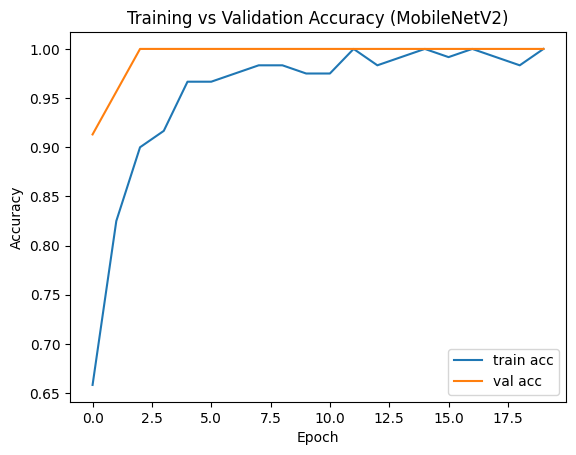

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (MobileNetV2)')
plt.show()

In [41]:
!pwd

/content


In [42]:
!git init

Reinitialized existing Git repository in /content/.git/


In [43]:
!ls -la

total 24
drwxr-xr-x 1 root root 4096 Jul 30 22:00 .
drwxr-xr-x 1 root root 4096 Jul 30 20:53 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config
drwx------ 5 root root 4096 Jul 30 22:00 drive
drwxr-xr-x 7 root root 4096 Jul 30 22:00 .git
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data


In [44]:
!cp -r /content/drive/MyDrive/ai_ml/apple_classifier/my_mobilenet_model.keras /content/drive/MyDrive/ai_ml/apple_classifier/* /Apple_Classification_GroupEE1

cp: target '/Apple_Classification_GroupEE1' is not a directory


In [46]:
!ls /content/drive/MyDrive/

'22_EG_EE_1980 (10).pdf'
'22_EG_EE_1980 (14) (1).pdf'
'22_EG_EE_1980 (14).pdf'
'22_EG_EE_1980 (29).pdf'
'22_EG_EE_1980 (30).pdf'
'22_EG_EE_1980 (35).pdf'
'Academic Transcript-compressed.pdf'
'Addressing the issue of fuel scarcity in Nigeria as an electrical and electronics engineer.gdoc'
'Admission Letter_01 (1).jpg'
'Admission Letter_01 (2).jpg'
'Admission Letter_01.jpg'
'Admission Letter (1).pdf'
'Admission Letter from School.jpg'
'Admission Letter.jpg'
'Admission Letter.pdf'
'Admission Letter-WPS Office-1.pdf'
'Admission Letter-WPS Office (1).pdf'
'Admission Letter-WPS Office.pdf'
 ai_ml
'archive (2).zip'
'Birth Certificate-WPS Office (1).pdf'
'Birth Certificate-WPS Office (2).pdf'
'Birth Certificate-WPS Office.pdf'
'Certificate of Origin (1).jpg'
'Certificate of OriginID_01.jpg'
'Certificate of Origin-WPS Office.pdf'
 Classroom
'Colab Notebooks'
'Course Form-WPS Office.pdf'
'Course Registration Form (1).jpg'
'Course Registration Form.jpg'
 datasets
'Entrepreneurship and Democracy.p

In [47]:
%cd /content/drive/MyDrive/ai_ml/apple_classifier
!pwd

/content/drive/MyDrive/ai_ml/apple_classifier
/content/drive/MyDrive/ai_ml/apple_classifier


In [49]:
!git init
!ls -la

Reinitialized existing Git repository in /content/drive/MyDrive/ai_ml/apple_classifier/.git/
total 10457
-rw------- 1 root root    76877 Jul 30 22:05 Apple_classifier.ipynb
drwx------ 2 root root     4096 Jul 30 20:15 datasets
drwx------ 7 root root     4096 Jul 30 22:06 .git
-rw------- 1 root root 10622189 Jul 30 21:20 my_mobilenet_model.keras


In [50]:
!rm -rf /content/.git